# Compared analysis of two-state PCCA

In [90]:
%load_ext autoreload
%autoreload 2 

data_folder = "../data/"

import numpy as np
import pandas as pd

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.minor.width": 0.7,
    "ytick.minor.width": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import plotting_utils as pu
from matplotlib.patches import Patch
from matplotlib import color_sequences
from matplotlib.colors import TwoSlopeNorm

#import networkx as nx # graph visualization of MSM microstates and macrostates model

from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## Prepare data for analysis


Reload data (after clustering)

In [91]:
trajectories_labels = ["tica_distances", "pca_distances", "tica_dihedrals", "pca_dihedrals"]


total_time_micros = 305
time_step_micros =  total_time_micros / 1526041 #/ distances.shape[0]
time_step_nanos = time_step_micros * 10**3
print("Time step (microseconds)", time_step_micros) # 2x10^-4 microseconds
print("Time step (nanoseconds)", time_step_micros * 10**3) # 0.2 nanoseconds
print("Time step (picoseconds)", time_step_micros * 10**6) # 200 picoseconds
one_microsecond_in_frames = int(1 / time_step_micros)
print("One microsecond in frames", one_microsecond_in_frames) # 5000 frames


# --------------------------------
# RMSD from crystal distances
# --------------------------------
crystal_dist = np.loadtxt(
    data_folder + "hp35.crystaldists",
    delimiter=" ",
    dtype=float
)

print("Crystal distances shape", crystal_dist.shape) 
rmsd = np.sqrt(np.mean(crystal_dist**2, axis=1))  # [nm]

Time step (microseconds) 0.00019986356854108112
Time step (nanoseconds) 0.19986356854108112
Time step (picoseconds) 199.86356854108112
One microsecond in frames 5003
Crystal distances shape (1526041, 53)


Fit MSM with previously chosen and validated lagtime

In [92]:
MSM_LAG_NS = 50
MSM_LAG_FRAMES = int(MSM_LAG_NS / time_step_nanos)
print("MSM lag time in frames:", MSM_LAG_FRAMES)
N_CLUSTERS = 50
tce = TransitionCountEstimator(lagtime=MSM_LAG_FRAMES, count_mode="sliding-effective")



msm_dict = {}
micro_trajectory_dict = {} # traj -> micro traj
dtrajs_dict = {} # traj -> micro traj



for i, name in enumerate(trajectories_labels):
    data = np.load(f"../intermediate_outputs/kmeans_plusplus/{N_CLUSTERS}clusters_{name}.npz")
    dtraj = data["traj"].copy()
    centers = data["centers"].copy()
    C = tce.fit(dtraj).fetch_model()
    submodel = C.submodel_largest(directed=True)
    print(f"Submodel for {name} has {submodel.n_states} microstates.")
    micro_trajectory_dict[name] = submodel.transform_discrete_trajectories_to_submodel(data["traj"])
    np.save(f"../intermediate_outputs/microstate_trajs/{N_CLUSTERS}clusters_{MSM_LAG_NS}lag_{name}_submodel.npy", micro_trajectory_dict[name])

    dtrajs_dict[name] = pu.clean_assignments(micro_trajectory_dict[name], max_dist= 10000)
    if np.any(dtrajs_dict[name] == -1):
        print(f"Warning: {name} has unassigned microstates after cleaning.")
    msm = MaximumLikelihoodMSM(reversible = True).fit(submodel).fetch_model()
    msm_dict[name] = msm

MSM lag time in frames: 250
Submodel for tica_distances has 50 microstates.
Submodel for pca_distances has 21 microstates.
Submodel for tica_dihedrals has 49 microstates.
Submodel for pca_dihedrals has 50 microstates.


Markov chain lag: 49.97 ns (250 frames)


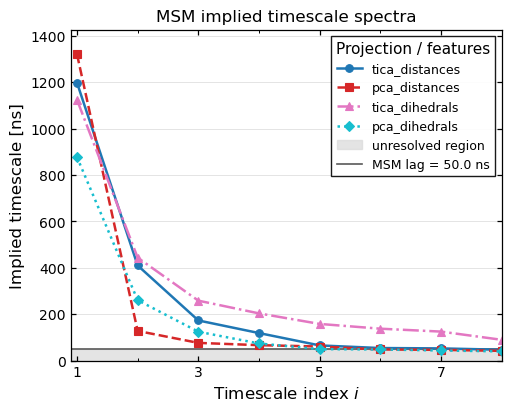

In [93]:
# ---------------------------------------------------------------------------
# Report-quality timescale spectrum plot: all MSMs in one panel

n_timescales = 8
msm_lag_ns = MSM_LAG_FRAMES * time_step_nanos
print(f"Markov chain lag: {msm_lag_ns:.2f} ns ({MSM_LAG_FRAMES} frames)")

# ---------------------------------------------------------------------------
# Figure

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories_labels)))
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for i, name in enumerate(trajectories_labels):
    msm = msm_dict[name]

    timescales_ns = np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos
    indices = np.arange(1, len(timescales_ns) + 1)


    ax.plot(
        indices,
        timescales_ns,
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=1.8,
        markersize=5.5,
        markeredgewidth=0.8,
        color=colors[i],
        label=rf"{name}"
    )

# ---------------------------------------------------------------------------
# MSM lag and threshold annotations

ax.axhspan(
    0,
    msm_lag_ns,
    color="0.85",
    alpha=0.7,
    zorder=0,
    label="unresolved region"
)

ax.axhline(
    msm_lag_ns,
    color="0.35",
    linestyle="-",
    linewidth=1.2,
    zorder=1,
    label=rf"MSM lag = {msm_lag_ns:.1f} ns"
)


# ---------------------------------------------------------------------------
# Axes formatting

ax.set_xlabel(r"Timescale index $i$")
ax.set_ylabel("Implied timescale [ns]")
ax.set_title("MSM implied timescale spectra")

ax.set_xlim(0.9, n_timescales)
ax.set_xticks(np.arange(1, n_timescales + 1, 2))
ax.set_xticks(np.arange(1, n_timescales + 1, 1), minor=True)

# Let the upper y-limit adapt to the data, threshold included
all_timescales = []

for name in trajectories_labels:
    msm = msm_dict[name]
    all_timescales.append(np.asarray(msm.timescales(k=n_timescales)) * time_step_nanos)

all_timescales = np.concatenate(all_timescales)
finite_timescales = all_timescales[np.isfinite(all_timescales)]

ymax = max(
    np.nanmax(finite_timescales),
    #threshold_ns,
    msm_lag_ns
)

ax.set_ylim(0, 1.08 * ymax)

ax.grid(
    which="major",
    axis="y",
    linestyle="-",
    linewidth=0.7,
    alpha=0.35
)

ax.grid(
    which="minor",
    axis="y",
    linestyle=":",
    linewidth=0.5,
    alpha=0.25
)

ax.legend(
    title="Projection / features",
    frameon=True,
    fancybox=False,
    edgecolor="black",
    framealpha=0.9,
    loc="best"
)
# ---------------------------------------------------------------------------
# Save figure
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.png",
    dpi=600,
    bbox_inches="tight"
)
fig.savefig(
    "../output_figures/msm_timescale_spectra_report.pdf",
    bbox_inches="tight"
)
plt.show()

---

Compute microstate PCCA assignments (soft and hard)

In [94]:
n_common = 2

pcca_dict = {}
pcca_memberships_dict = {}
macro_assignments_micro_dict = {}

for name in trajectories_labels:
    msm = msm_dict[name]

    pcca = msm.pcca(n_common)
    pcca_dict[name] = pcca

    # shape: n_microstates x 2
    memberships = pcca.memberships
    pcca_memberships_dict[name] = memberships

    # hard assignment of each microstate
    macro_assignments_micro = memberships.argmax(axis=1)
    macro_assignments_micro_dict[name] = macro_assignments_micro

Project onto the timeseries (soft and hard)

In [95]:
pcca_probabilities_timeseries_dict = {}
hard_assignments_timeseries_dict = {}

for name in trajectories_labels:
    dtraj = dtrajs_dict[name]
    memberships = pcca_memberships_dict[name]


    # probability of belonging to macrostate 1
    p_macro1 = memberships[dtraj, 1]

    # hard macrostate assignment
    hard = np.argmax(memberships[dtraj, :], axis=1)


    pcca_probabilities_timeseries_dict[name] = p_macro1
    hard_assignments_timeseries_dict[name] = hard

#### Cored trajectory - compared pipelines

In [96]:
def core_two_state_trajectory(hard, min_core_frames):
    """
    Apply temporal coring to a discrete two-state trajectory.

    A transition from the current state to a new state is accepted only if
    the trajectory remains continuously in the new state for at least
    `min_core_frames`.

    Parameters
    ----------
    hard : array-like
        Discrete trajectory containing state labels 0 and 1.
    min_core_frames : int
        Minimum consecutive number of frames required to accept a new state.

    Returns
    -------
    cored : np.ndarray
        Cored trajectory with the same shape as `hard`.
    """
    hard = np.asarray(hard, dtype=int)

    if hard.ndim != 1:
        raise ValueError("hard must be a one-dimensional trajectory.")

    if len(hard) == 0:
        return hard.copy()

    if not np.all(np.isin(hard, [0, 1])):
        raise ValueError("hard must contain only state labels 0 and 1.")

    min_core_frames = max(1, int(min_core_frames))

    cored = np.empty_like(hard)

    current_state = hard[0]
    cored[:] = current_state

    candidate_state = None
    candidate_start = None
    candidate_length = 0

    for i in range(1, len(hard)):
        observed_state = hard[i]

        if observed_state == current_state:
            # Returned to the current core before completing a transition
            candidate_state = None
            candidate_start = None
            candidate_length = 0
            cored[i] = current_state
            continue

        if observed_state == candidate_state:
            candidate_length += 1
        else:
            # Start testing a different candidate state
            candidate_state = observed_state
            candidate_start = i
            candidate_length = 1

        if candidate_length >= min_core_frames:
            # Accept the transition retroactively from its first frame
            current_state = candidate_state
            cored[candidate_start:i + 1] = current_state

            candidate_state = None
            candidate_start = None
            candidate_length = 0
        else:
            # Candidate has not yet remained long enough
            cored[i] = current_state

    return cored


min_core_markov_steps = 1

min_core_mus = (
    min_core_markov_steps
    * MSM_LAG_NS
    / 1000
)

min_core_frames = max(
    1,
    int(np.ceil(min_core_mus / time_step_micros))
)

print("Minimum core time:", min_core_mus, "µs")
print("Minimum core frames:", min_core_frames)


cored_assignments_timeseries_dict = {}

for name in trajectories_labels:
    hard = hard_assignments_timeseries_dict[name]

    cored_assignments_timeseries_dict[name] = (
        core_two_state_trajectory(
            hard,
            min_core_frames=min_core_frames
        )
    )

Minimum core time: 0.05 µs
Minimum core frames: 251


Plot

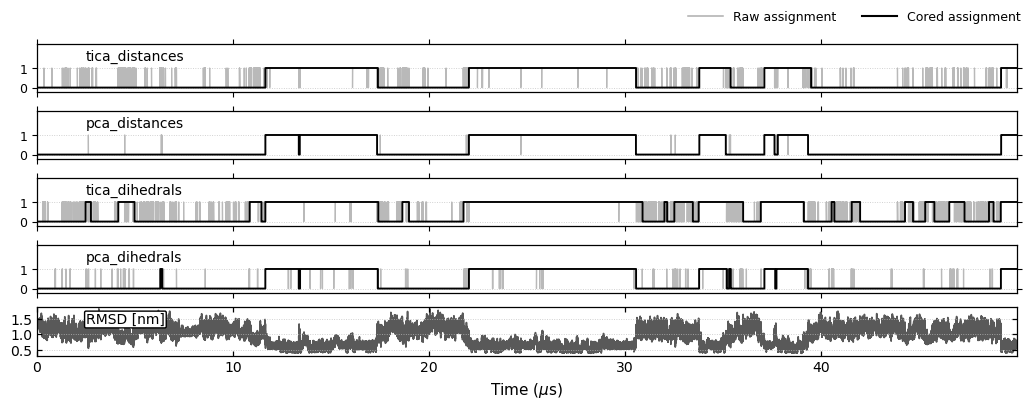

In [97]:
from matplotlib.lines import Line2D


# -----------------------------------------------------------
# Time window
# ------------------------------------------------------------
tmin_mus = 0
tmax_mus = 50

frame_min = max(
    0,
    int(np.floor(tmin_mus / time_step_micros))
)

frame_max = min(
    len(hard_assignments_timeseries_dict[trajectories_labels[0]]),
    int(np.ceil(tmax_mus / time_step_micros))
)

if frame_max <= frame_min:
    raise ValueError("The selected time window contains no trajectory frames.")

time_mus = (
    np.arange(frame_min, frame_max)
    * time_step_micros
)


# ------------------------------------------------------------
# Labels shown in the figure
# ------------------------------------------------------------



# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
n_models = len(trajectories_labels)

fig, axs = plt.subplots(
    nrows=n_models + 1,
    ncols=1,
    figsize=(10.2,  4.),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

axs = np.atleast_1d(axs)

for panel_index, (ax, name) in enumerate(
    zip(axs, trajectories_labels)
):
    raw = np.asarray(
        hard_assignments_timeseries_dict[name][frame_min:frame_max]
    )
    cored = np.asarray(
        cored_assignments_timeseries_dict[name][frame_min:frame_max]
    )

    if len(raw) != len(time_mus) or len(cored) != len(time_mus):
        raise ValueError(
            f"Trajectory length mismatch for model '{name}'."
        )

    # Raw assignment: secondary information
    ax.step(
        time_mus,
        raw,
        where="post",
        color="0.68",
        linewidth=0.9,
        alpha=0.85,
        zorder=1
    )

    # Cored assignment: primary information
    ax.step(
        time_mus,
        cored,
        where="post",
        color="black",
        linewidth=1.35,
        zorder=2
    )



    # Panel label
    ax.text(
        +0.05,
        0.88,
        f"{name}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
    )

    # State axis
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["0", "1"])
    ax.set_ylim(-0.25, 2.25)

    # Light horizontal guides
    ax.grid(
        axis="y",
        linestyle=":",
        linewidth=0.65,
        color="0.75",
        alpha=0.8,
        zorder=0
    )



    ax.tick_params(
        axis="both",
        which="major",
        labelsize=9,
        direction="out",
        length=3.5,
        width=0.8
    )

# Plot RMSD
axs[-1].plot(
    time_mus,
    rmsd[frame_min:frame_max],
    color="0.35",
    linewidth=1.2,
    label="RMSD from crystal distances",
    zorder=0
)
axs[-1].set_ylabel("")
axs[-1].text(
    0.05,
    0.88,
    "RMSD [nm]",
    transform=axs[-1].transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.1"
    )
)
axs[-1].grid(which = "major", axis = "y", linestyle = ":", linewidth = 0.65, color = "0.75", alpha = 0.8, zorder = 0)


# Shared limits and labels
axs[-1].set_xlim(tmin_mus, min(tmax_mus, time_mus[-1]))
axs[-1].set_xlabel(r"Time ($\mu$s)", fontsize=11)




# ------------------------------------------------------------
# Single shared legend
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0], [0],
        color="0.68",
        linewidth=1.1,
        label="Raw assignment"
    ),
    Line2D(
        [0], [0],
        color="black",
        linewidth=1.5,
        label="Cored assignment"
    )
]

fig.legend(
    handles=legend_handles,
    loc="outside upper right",
    frameon=False,
    fontsize=9,
    handlelength=2.8,
    ncols=2
)

# Optional export
fig.savefig(
     "../output_figures/two_state_raw_vs_cored_assignments.pdf",
     bbox_inches="tight"
 )

plt.show()

### Estimation of folding times from the cored trajectory

In [50]:
def transition_indices(two_state_traj):
    two_state_traj = np.asarray(two_state_traj)
    return np.where(np.diff(two_state_traj) != 0)[0] + 1

def residence_times(two_state_traj, state, time_step_micros):
    """
    Residence times in a given state from a cored 0/1 trajectory.
    Returns times in microseconds.
    """
    traj = np.asarray(two_state_traj, dtype=int)

    change_points = np.where(np.diff(traj) != 0)[0] + 1
    starts = np.r_[0, change_points]
    ends = np.r_[change_points, len(traj)]

    times = []

    for start, end in zip(starts, ends):
        if traj[start] == state:
            duration_frames = end - start
            times.append(duration_frames * time_step_micros)

    return np.asarray(times)






transition_indices_dict = {}

for name in trajectories_labels:
    transition_indices_dict[name] = transition_indices(
        cored_assignments_timeseries_dict[name]
    )


residence_times_unfolded_dict = {}
residence_times_folded_dict = {}

for name in trajectories_labels:
    cored = cored_assignments_timeseries_dict[name]

    residence_times_unfolded_dict[name] = residence_times(
        cored,
        state=0,
        time_step_micros=time_step_micros
    )

    residence_times_folded_dict[name] = residence_times(
        cored,
        state=1,
        time_step_micros=time_step_micros
    )

In [51]:
unfolded_rows = []

for name in trajectories_labels:
    times_U = np.asarray(residence_times_unfolded_dict[name], dtype=float)

    unfolded_rows.append({
        "Model": name.replace("_", r"\_"),
        r"$N_{\mathrm{visits}}$": len(times_U),
        r"Mean waiting time [$\mu$s]": times_U.mean(),
        r"Median waiting time [$\mu$s]": np.median(times_U),
    })

unfolded_waiting_df = pd.DataFrame(unfolded_rows)

display(unfolded_waiting_df)

,Model,$N_{\mathrm{visits}}$,Mean waiting time [$\mu$s],Median waiting time [$\mu$s]
0,tica\_distances,35,2.712046,1.725022
1,pca\_distances,37,2.664894,1.702838
2,tica\_dihedrals,46,1.649787,1.014408
3,pca\_dihedrals,42,2.286948,1.192186


Plot distributions

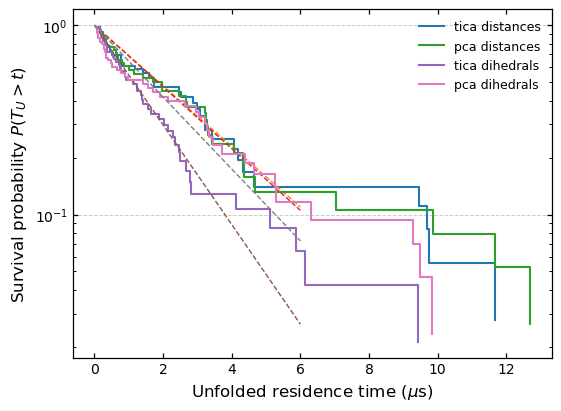

In [52]:
fig, ax = plt.subplots(figsize=(5.5, 4), constrained_layout=True)

for name in trajectories_labels:
    times = np.asarray(residence_times_unfolded_dict[name], dtype=float)
    times = np.sort(times)

    # Empirical survival probability P(T > t)
    survival = 1.0 - np.arange(1, len(times) + 1) / (len(times) + 1)

    ax.step(
        times,
        survival,
        where="post",
        linewidth=1.5,
        label=name.replace("_", " ")
    )

    # Exponential estimate using the sample mean
    mean_time = times.mean()
    t_fit = np.linspace(0, 6, 300)

    ax.plot(
        t_fit,
        np.exp(-t_fit / mean_time),
        linestyle="--",
        linewidth=1.0
    )

ax.set_yscale("log")
ax.set_xlabel(r"Unfolded residence time ($\mu$s)")
ax.set_ylabel(r"Survival probability $P(T_U > t)$")

ax.grid(which = "major", axis = "y", linestyle = "--", linewidth = 0.7, color = "0.75", alpha = 0.8, zorder = 0)
ax.legend(frameon=False)


plt.savefig(
    "../output_figures/unfolded_residence_times_survival.pdf",
    bbox_inches="tight"
)
plt.show()

Make latex table

In [53]:
latex_table = unfolded_waiting_df.to_latex(
    index=False,
    escape=False,
    float_format="%.3f",
    caption=(
        r"Empirical unfolded-state residence times computed from the cored "
        r"macrostate trajectory. $N_{\mathrm{visits}}$ is the number of "
        r"unfolded visits observed in the trajectory."
    ),
    label="tab:empirical_unfolded_residence_times"
)

print(latex_table)

\begin{table}
\caption{Empirical unfolded-state residence times computed from the cored macrostate trajectory. $N_{\mathrm{visits}}$ is the number of unfolded visits observed in the trajectory.}
\label{tab:empirical_unfolded_residence_times}
\begin{tabular}{lrrr}
\toprule
Model & $N_{\mathrm{visits}}$ & Mean waiting time [$\mu$s] & Median waiting time [$\mu$s] \\
\midrule
tica\_distances & 35 & 2.712 & 1.725 \\
pca\_distances & 37 & 2.665 & 1.703 \\
tica\_dihedrals & 46 & 1.650 & 1.014 \\
pca\_dihedrals & 42 & 2.287 & 1.192 \\
\bottomrule
\end{tabular}
\end{table}



Align models: after this step, "macrostate 0" should mean approximately the same in all models

In [98]:
reference_name = trajectories_labels[0] # tica_distances

ref_hard = hard_assignments_timeseries_dict[reference_name]

for name in trajectories_labels:
    if name == reference_name:
        continue

    hard = hard_assignments_timeseries_dict[name]

    same_agreement = np.mean(hard == ref_hard)
    flipped_agreement = np.mean((1 - hard) == ref_hard)

    if flipped_agreement > same_agreement:
        print(f"Flipping labels for {name}")

        # flip frame-wise hard labels
        hard_assignments_timeseries_dict[name] = 1 - hard_assignments_timeseries_dict[name]

        # flip frame-wise probability P(state 1)
        pcca_probabilities_timeseries_dict[name] = 1.0 - pcca_probabilities_timeseries_dict[name]

        # flip microstate membership columns
        pcca_memberships_dict[name] = pcca_memberships_dict[name][:, ::-1]

        # update microstate hard assignments
        macro_assignments_micro_dict[name] = 1 - macro_assignments_micro_dict[name]

Compare fuzzy membership probabilities

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3774/775953230.py:119: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.96])


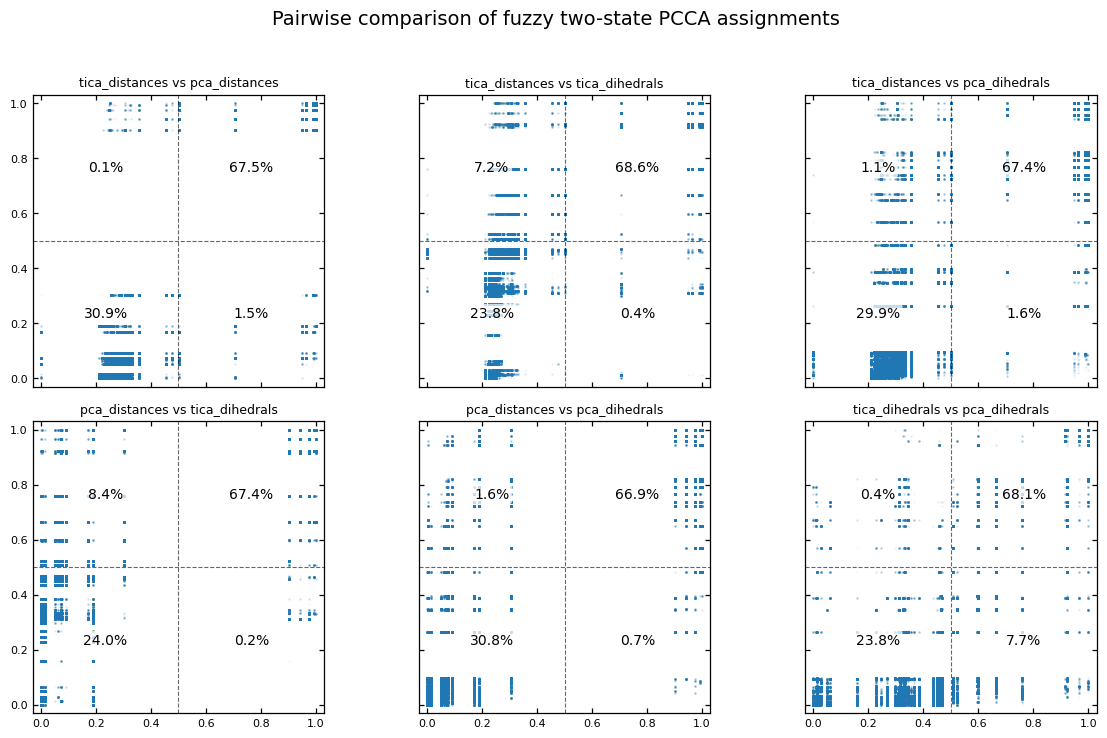

In [99]:
from itertools import combinations

def quadrant_fractions(pi, pj, threshold=0.5):

    """
    Returns fractions of frames in the four quadrants defined by threshold.
    x-axis: pi
    y-axis: pj
    """
    q00 = np.mean((pi < threshold) & (pj < threshold))  # both basin 0
    q10 = np.mean((pi >= threshold) & (pj < threshold)) # x basin 1, y basin 0
    q01 = np.mean((pi < threshold) & (pj >= threshold)) # x basin 0, y basin 1
    q11 = np.mean((pi >= threshold) & (pj >= threshold))# both basin 1
    return {
        "q00": q00,
        "q10": q10,
        "q01": q01,
        "q11": q11,
    }

def add_quadrant_annotations(ax, quad, fontsize=8):

    """
    Add quadrant percentages in axes coordinates.
    """

    ax.text(
        0.25, 0.25,
        f"{100 * quad['q00']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize +2,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75, edgecolor="none")
    )

    ax.text(
        0.75, 0.25,
        f"{100 * quad['q10']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize +2,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75, edgecolor="none")
    )

    ax.text(
        0.25, 0.75,
        f"{100 * quad['q01']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize +2,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75, edgecolor="none")
    )

    ax.text(
        0.75, 0.75,
        f"{100 * quad['q11']:.1f}%",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=fontsize +2,
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.75, edgecolor="none")
    )





pairs = list(combinations(trajectories_labels, 2))

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(12, 7.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

axs = axs.flatten()

for ax, (name_i, name_j) in zip(axs, pairs):
    pi = pcca_probabilities_timeseries_dict[name_i]
    pj = pcca_probabilities_timeseries_dict[name_j]

    quad = quadrant_fractions(pi, pj, threshold=0.5)

    ax.scatter(
        pi,
        pj,
        s=0.7,
        alpha=0.03,
        rasterized=True
    )

    ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.6)

    add_quadrant_annotations(ax, quad, fontsize=8)
    
    ax.set_xlim(-0.03, 1.03)
    ax.set_ylim(-0.03, 1.03)
    ax.set_aspect("equal")

    ax.set_title(f"{name_i} vs {name_j}", fontsize=9)

    ax.set_xlabel("")
    ax.set_ylabel(f"")

    ax.tick_params(axis="both", labelsize=8)

fig.suptitle(
    "Pairwise comparison of fuzzy two-state PCCA assignments",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "../output_figures/pairwise_pcca_membership_scatter_quadrants_report.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "../output_figures/pairwise_pcca_membership_scatter_quadrants_report.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

Fuzzy equilibrium populations

$
P(frame \in A) = \sum_{\text{micro}} p(frame \in \text{micro}) \cdot p(\text{micro} \in A)
$

In [100]:
state_populations = {}

for name in trajectories_labels:
    pops = np.asarray(pcca_dict[name].coarse_grained_stationary_probability)

    # Optional safety check
    if len(pops) != 2:
        raise ValueError(f"{name}: expected 2 macrostates, got {len(pops)}")

    state_populations[name] = pops


population_df = pd.DataFrame.from_dict(
    state_populations,
    orient="index",
    columns=["$P(S_0)$", "$P(S_1)$"]
)

population_df.index.name = "Model"


T = 360  # K
#kBT_joule = 0.008314462618 * T  # kJ/mol
kBT = 0.0019872043*T  # kcal/mol/K


population_df["$\\Delta G_{1-0}$ (kcal mol$^{-1}$)"] = (
    -kBT * np.log(population_df["$P(S_1)$"] / population_df["$P(S_0)$"])
)

latex_df = population_df.reset_index()

latex_table = latex_df.to_latex(
    index=False,
    float_format="%.3f",
    escape=False,
    caption=(
        "Coarse-grained stationary populations of the two PCCA macrostates "
        "for each MSM at the common two-state resolution. Relative free energies "
        "were computed as $\\Delta G_{1-0} = -k_B T \\ln[P(S_1)/P(S_0)]$ "
        f"with $T={T}$ K."
    ),
    label="tab:pcca_two_state_populations",
    column_format="lccc"
)

print(latex_table)

\begin{table}
\caption{Coarse-grained stationary populations of the two PCCA macrostates for each MSM at the common two-state resolution. Relative free energies were computed as $\Delta G_{1-0} = -k_B T \ln[P(S_1)/P(S_0)]$ with $T=360$ K.}
\label{tab:pcca_two_state_populations}
\begin{tabular}{lccc}
\toprule
Model & $P(S_0)$ & $P(S_1)$ & $\Delta G_{1-0}$ (kcal mol$^{-1}$) \\
\midrule
tica_distances & 0.230 & 0.770 & -0.863 \\
pca_distances & 0.303 & 0.697 & -0.596 \\
tica_dihedrals & 0.218 & 0.782 & -0.915 \\
pca_dihedrals & 0.358 & 0.642 & -0.417 \\
\bottomrule
\end{tabular}
\end{table}



Define core and ambiguous frame masks

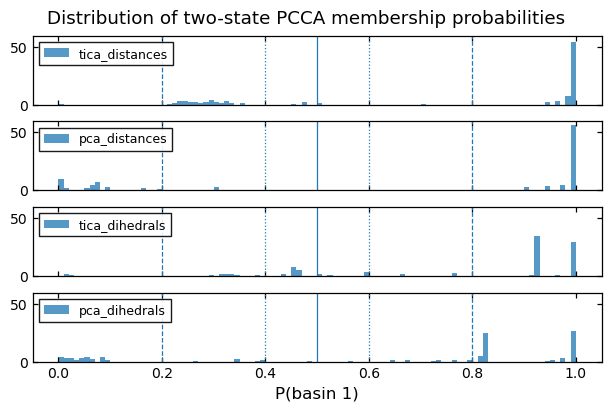

In [101]:
fig, axs = plt.subplots(
    nrows=len(trajectories_labels),
    ncols=1,
    figsize=(6, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

bins = np.linspace(0, 1, 101)

for ax, name in zip(axs, trajectories_labels):
    p = pcca_probabilities_timeseries_dict[name]

    ax.hist(
        p,
        bins=bins,
        density=True,
        alpha=0.75,
        label = name
    )

    ax.axvline(0.2, linestyle="--", linewidth=0.9)
    ax.axvline(0.4, linestyle=":", linewidth=0.9)
    ax.axvline(0.5, linestyle="-", linewidth=0.9)
    ax.axvline(0.6, linestyle=":", linewidth=0.9)
    ax.axvline(0.8, linestyle="--", linewidth=0.9)
    ax.legend(title="", frameon=True, fancybox=False, edgecolor="black", framealpha=0.9, loc="upper left")
    ax.set_ylabel("")

axs[-1].set_xlabel("P(basin 1)")
fig.suptitle("Distribution of two-state PCCA membership probabilities")

plt.savefig("../output_figures/pcca_membership_probability_distributions.png", dpi=300, bbox_inches="tight")
plt.savefig("../output_figures/pcca_membership_probability_distributions.pdf", bbox_inches="tight")
plt.show()

Structural caracterization of macrostate 1

In [58]:
region_masks_dict = {}

for name in trajectories_labels:
    p = pcca_probabilities_timeseries_dict[name]

    region_masks_dict[name] = {
        "state0_core": p < 0.4,
        "state1_core": p > 0.6,
        "ambiguous": (p > 0.4) & (p < 0.6),
    }

Core-overlap matrices


$$J = \frac{|A \cap B|}{|A \cup B |}$$

In [59]:
def jaccard(mask_a, mask_b):
    union = np.sum(mask_a | mask_b)
    if union == 0:
        return np.nan
    return np.sum(mask_a & mask_b) / union


core_overlap_state0 = np.zeros((4, 4))
core_overlap_state1 = np.zeros((4, 4))
ambiguous_overlap = np.zeros((4, 4))

for i, name_i in enumerate(trajectories_labels):
    for j, name_j in enumerate(trajectories_labels):
        masks_i = region_masks_dict[name_i]
        masks_j = region_masks_dict[name_j]

        core_overlap_state0[i, j] = jaccard(
            masks_i["state0_core"],
            masks_j["state0_core"]
        )

        core_overlap_state1[i, j] = jaccard(
            masks_i["state1_core"],
            masks_j["state1_core"]
        )

        ambiguous_overlap[i, j] = jaccard(
            masks_i["ambiguous"],
            masks_j["ambiguous"]
        )

In [60]:
name_map = {
    "tica_distances": "tICA distances",
    "pca_distances": "PCA distances",
    "tica_dihedrals": "tICA dihedrals",
    "pca_dihedrals": "PCA dihedrals",
}

overlap_rows = []

for i, name_i in enumerate(trajectories_labels):
    for j, name_j in enumerate(trajectories_labels):
        if i < j:
            overlap_rows.append({
                "Model pair": f"{name_map.get(name_i, name_i)} -- {name_map.get(name_j, name_j)}",
                "Core overlap $S_0$": core_overlap_state0[i, j],
                "Core overlap $S_1$": core_overlap_state1[i, j],
                "Ambiguous overlap": ambiguous_overlap[i, j],
            })

overlap_df = pd.DataFrame(overlap_rows)

overlap_latex = overlap_df.to_latex(
    index=False,
    float_format="%.3f",
    escape=False,
    caption=(
        "Pairwise Jaccard overlaps between high-confidence PCCA regions "
        "defined from fuzzy membership probabilities. Core regions were "
        "defined as $P(S_1)<0.4$ for basin $S_0$ and $P(S_1)>0.6$ for basin "
        "$S_1$, while ambiguous frames were defined by $0.4<P(S_1)<0.6$."
    ),
    label="tab:pcca_core_overlap",
    column_format="lccc"
)

print(overlap_latex)

\begin{table}
\caption{Pairwise Jaccard overlaps between high-confidence PCCA regions defined from fuzzy membership probabilities. Core regions were defined as $P(S_1)<0.4$ for basin $S_0$ and $P(S_1)>0.6$ for basin $S_1$, while ambiguous frames were defined by $0.4<P(S_1)<0.6$.}
\label{tab:pcca_core_overlap}
\begin{tabular}{lccc}
\toprule
Model pair & Core overlap $S_0$ & Core overlap $S_1$ & Ambiguous overlap \\
\midrule
tICA distances -- PCA distances & 0.877 & 0.991 & 0.000 \\
tICA distances -- tICA dihedrals & 0.348 & 0.961 & 0.131 \\
tICA distances -- PCA dihedrals & 0.852 & 0.965 & 0.020 \\
PCA distances -- tICA dihedrals & 0.312 & 0.962 & 0.000 \\
PCA distances -- PCA dihedrals & 0.928 & 0.965 & 0.000 \\
tICA dihedrals -- PCA dihedrals & 0.319 & 0.952 & 0.016 \\
\bottomrule
\end{tabular}
\end{table}



In [61]:
folded_core_consensus = (
    region_masks_dict["tica_distances"]["state1_core"] &
    region_masks_dict["pca_distances"]["state1_core"] &
    region_masks_dict["tica_dihedrals"]["state1_core"]
)

folded_mask = folded_core_consensus
other_mask = ~folded_core_consensus

print("Folded frames:", folded_mask.sum())
print("Other frames:", other_mask.sum())
print("Folded fraction:", folded_mask.mean())

Folded frames: 1026421
Other frames: 499620
Folded fraction: 0.6726038160180493


Core-set overlaps show that the folded basin is the most robust feature of the two-state decompositions. The folded core, corresponding to basin 1, is almost identical between tica_distances, pca_distances, and tica_dihedrals, with Jaccard overlaps of approximately 0.98–0.99. In contrast, overlaps for basin 0 are substantially lower, indicating that the non-folded ensemble is more heterogeneous and representation-dependent. The ambiguous regions show very low overlap across models, suggesting that the precise boundary between basins is not robust to the choice of features and dimensional reduction. Therefore, subsequent structural interpretation should focus primarily on the robust folded core, while treating the non-folded basin and transition-like frames with more caution.

#### Save folded frames for later PyMol visualization

In [62]:
filepath = "../intermediate_outputs/frame_lists/"
os.makedirs(filepath, exist_ok=True)

filename = os.path.join(filepath, "folded_core_consensus_frames.npy")
np.save(filename, np.where(folded_mask)[0])

---
# Structural analysis of the folded basin (robust S1 core)

Define a *score* for contact importance that takes into consideration both the difference in the distance and the difference in the formation probability according to the cutoff.



$$
d^{\mathrm{robust}}_{ij}
=
\frac{
\mathrm{median}(r_{ij}^{\mathrm{other}})
-
\mathrm{median}(r_{ij}^{\mathrm{folded}})
}{
\mathrm{IQR}_{\mathrm{pooled}}
}
$$

So, in words we say that a contact is important if its distance distribution is
-  substantially shifted toward shorter distances in the folded basin.
- substantially more narrow in the folded basin.

Load descriptor timeseries

In [63]:
contacts_timeseries = np.loadtxt(data_folder + "hp35.crystaldists", delimiter = " ", dtype = float)
contacts_index = np.loadtxt(data_folder + "hp35.crystaldists.ndx", delimiter = " ", dtype = int)

contact_cutoff = 0.4 # nm

def summarize_contact_array(x, cutoff):
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "iqr": np.quantile(x, 0.75) - np.quantile(x, 0.25),
        "formed_fraction": np.mean(x < cutoff),
    }

In [64]:
contact_rows = []

for k, pair in enumerate(contacts_index):
    x = contacts_timeseries[:, k]

    folded_stats = summarize_contact_array(x[folded_mask], contact_cutoff)
    other_stats = summarize_contact_array(x[other_mask], contact_cutoff)

    row = {
        "contact": tuple(pair),
        "res_i": pair[0],
        "res_j": pair[1],

        "mean_folded": folded_stats["mean"],
        "std_folded": folded_stats["std"],
        "median_folded": folded_stats["median"],
        "q25_folded": folded_stats["q25"],
        "q75_folded": folded_stats["q75"],
        "iqr_folded": folded_stats["iqr"],
        "formed_fraction_folded": folded_stats["formed_fraction"],

        "mean_other": other_stats["mean"],
        "std_other": other_stats["std"],
        "median_other": other_stats["median"],
        "iqr_other": other_stats["iqr"],
        "formed_fraction_other": other_stats["formed_fraction"],
    }

    row["delta_mean"] = row["mean_other"] - row["mean_folded"]
    row["delta_fraction"] = (
        row["formed_fraction_folded"] - row["formed_fraction_other"]
    )

    contact_rows.append(row)

all_contact_df = pd.DataFrame(contact_rows)

all_contact_df = all_contact_df.sort_values(
    "delta_fraction",
    ascending=False
)


# ---------------------------------------------------------------------
#  compute Median/IQR-based cutoff-free score
# ---------------------------------------------------------------------

eps = 1e-12
all_contact_df["pooled_iqr"] = 0.5 * (
    all_contact_df["iqr_folded"] + all_contact_df["iqr_other"]
)

all_contact_df["robust_distance_effect_size"] = (
    all_contact_df["median_other"] - all_contact_df["median_folded"]
) / (all_contact_df["pooled_iqr"] + eps)


ranked_contacts_robust = all_contact_df.sort_values(
    "robust_distance_effect_size",
    ascending=False
)#[:10]



cols_to_show = [
    "contact",
    "res_i",
    "res_j",
    "mean_folded",
    "mean_other",
    "median_folded",
    "median_other",
    "iqr_folded",
    "iqr_other",
    "robust_distance_effect_size",
    "formed_fraction_folded",
    "formed_fraction_other",
    "delta_fraction",
]

ranked_contacts_robust[cols_to_show].head(10)


,contact,res_i,res_j,mean_folded,mean_other,median_folded,median_other,iqr_folded,iqr_other,robust_distance_effect_size,formed_fraction_folded,formed_fraction_other,delta_fraction
18,"(7, 12)",7,12,0.376888,1.014845,0.36972,1.041940,0.04751,0.474980,2.573140,0.779607,0.045533,0.734074
20,"(9, 32)",9,32,0.477081,1.628596,0.35941,1.640990,0.13433,0.926532,2.416110,0.661192,0.023692,0.637500
16,"(6, 17)",6,17,0.441643,1.405582,0.42214,1.391020,0.10148,0.752170,2.269970,0.363450,0.010026,0.353425
19,"(7, 13)",7,13,0.510632,1.144630,0.48771,1.164370,0.09004,0.513863,2.240958,0.024507,0.001365,0.023142
15,"(6, 14)",6,14,0.490508,1.242122,0.48822,1.216910,0.12059,0.567350,2.118470,0.149847,0.008254,0.141593
25,"(10, 32)",10,32,0.587497,1.613569,0.53052,1.610980,0.21037,0.964515,1.839261,0.154169,0.006933,0.147235
17,"(7, 11)",7,11,0.332125,0.695393,0.31751,0.717700,0.05284,0.383140,1.835818,0.919929,0.187773,0.732156
26,"(10, 34)",10,34,0.566828,1.564833,0.45376,1.535010,0.18820,0.997122,1.824398,0.259529,0.013448,0.246081
24,"(10, 29)",10,29,0.548418,1.441859,0.52988,1.440735,0.16540,0.843463,1.805707,0.043568,0.005402,0.038166
14,"(6, 13)",6,13,0.567120,1.265992,0.59051,1.247860,0.20228,0.554412,1.737430,0.105136,0.008430,0.096706


Make table for latex

In [65]:
top10_contacts_table = ranked_contacts_robust[
    [
        "res_i",
        "res_j",
        "median_folded",
        "median_other",
        "iqr_folded",
        "iqr_other",
        "robust_distance_effect_size",
        "formed_fraction_folded",
        "formed_fraction_other",
        "delta_fraction",
    ]
].head(10).copy()

top10_contacts_table["Contact"] = (
    top10_contacts_table["res_i"].astype(int).astype(str)
    + "--"
    + top10_contacts_table["res_j"].astype(int).astype(str)
)

top10_contacts_table = top10_contacts_table[
    [
        "Contact",
        "median_folded",
        "median_other",
        "iqr_folded",
        "robust_distance_effect_size",
        "formed_fraction_folded",
        "formed_fraction_other",
        "delta_fraction",
    ]
]

top10_contacts_table = top10_contacts_table.rename(columns={
    "median_folded": r"$\tilde r_\mathrm{folded}$",
    "median_other": r"$\tilde r_\mathrm{other}$",
    "iqr_folded": r"$\mathrm{IQR}_\mathrm{folded}$",
    "robust_distance_effect_size": r"$d_\mathrm{robust}$",
    "formed_fraction_folded": r"$P_\mathrm{folded}$",
    "formed_fraction_other": r"$P_\mathrm{other}$",
    "delta_fraction": r"$\Delta P$",
})

latex_top10_contacts = top10_contacts_table.to_latex(
    index=False,
    float_format="%.3f",
    escape=False,
    caption=(
        "Top ten residue contacts ranked by the cutoff-free robust folded-contact "
        "score. Distances are reported in nm. The robust effect size "
        "$d_\\mathrm{robust}$ compares the median contact distance outside and "
        "inside the folded basin, normalized by the pooled interquartile range. "
        "Contact probabilities were computed using a 0.8 nm cutoff and are "
        "reported only as auxiliary descriptors."
    ),
    label="tab:top10_folded_contacts",
    column_format="lccccccc"
)

print(latex_top10_contacts)

\begin{table}
\caption{Top ten residue contacts ranked by the cutoff-free robust folded-contact score. Distances are reported in nm. The robust effect size $d_\mathrm{robust}$ compares the median contact distance outside and inside the folded basin, normalized by the pooled interquartile range. Contact probabilities were computed using a 0.8 nm cutoff and are reported only as auxiliary descriptors.}
\label{tab:top10_folded_contacts}
\begin{tabular}{lccccccc}
\toprule
Contact & $\tilde r_\mathrm{folded}$ & $\tilde r_\mathrm{other}$ & $\mathrm{IQR}_\mathrm{folded}$ & $d_\mathrm{robust}$ & $P_\mathrm{folded}$ & $P_\mathrm{other}$ & $\Delta P$ \\
\midrule
7--12 & 0.370 & 1.042 & 0.048 & 2.573 & 0.780 & 0.046 & 0.734 \\
9--32 & 0.359 & 1.641 & 0.134 & 2.416 & 0.661 & 0.024 & 0.637 \\
6--17 & 0.422 & 1.391 & 0.101 & 2.270 & 0.363 & 0.010 & 0.353 \\
7--13 & 0.488 & 1.164 & 0.090 & 2.241 & 0.025 & 0.001 & 0.023 \\
6--14 & 0.488 & 1.217 & 0.121 & 2.118 & 0.150 & 0.008 & 0.142 \\
10--32 & 0.531 

Contact map

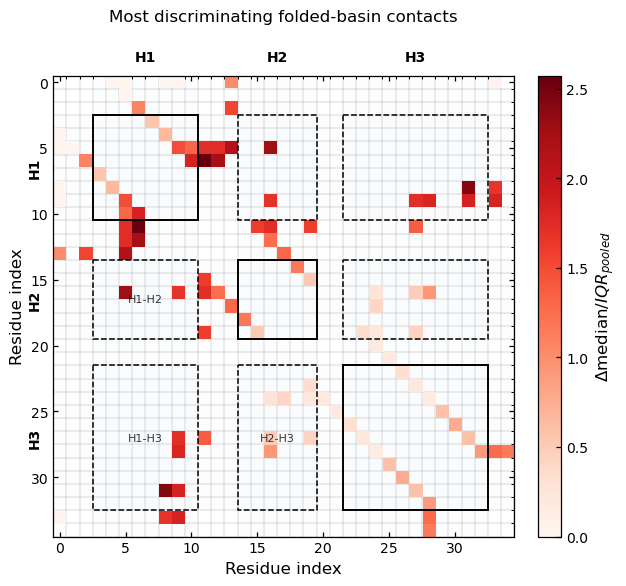

In [66]:
n_res = 35


# Build filtered contact map
contact_map_filtered = np.full((n_res, n_res), np.nan)

for _, row in ranked_contacts_robust.iterrows():
    i = int(row["res_i"]) -1 
    j = int(row["res_j"]) -1
    #value = row["median_other"] - row["median_folded"]
    value = row["robust_distance_effect_size"]
    contact_map_filtered[i, j] = value
    contact_map_filtered[j, i] = value


helix_ranges = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

fig, ax = plt.subplots(figsize=(7, 6))

# --- light background shading for helix rows/columns ---
for hname, (start, end) in helix_ranges.items():
    # vertical helix band
    ax.axvspan(
        start - 0.5,
        end + 0.5,
        alpha=0.01,
        zorder=0
    )

    # horizontal helix band
    ax.axhspan(
        start - 0.5,
        end + 0.5,
        alpha=0.01,
        zorder=0
    )

# --- main contact map ---
im = ax.imshow(
    contact_map_filtered,
    origin="lower",
    vmin=0,
    #vmax=1,
    zorder=2,
    cmap = "Reds"
)

# --- grid ---
ax.set_xticks(np.arange(-0.5, n_res, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_res, 1), minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.35, alpha=0.6)
ax.tick_params(which="minor", bottom=False, left=False)

# --- helix boundaries and labels ---
for hname, (start, end) in helix_ranges.items():
    width = end - start + 1

    # square block around same-helix region
    rect = Rectangle(
        (start - 0.5, start - 0.5),
        width,
        width,
        fill=False,
        linestyle="-",
        linewidth=1.4,
        zorder=4
    )
    ax.add_patch(rect)

    # axis labels for helices
    center = (start + end) / 2

    ax.text(
        center,
        -1.9,
        hname,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        clip_on=False
    )

    ax.text(
        -1.9,
        center,
        hname,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        rotation=90,
        clip_on=False
    )

# --- boxes around inter-helix regions ---
helix_items = list(helix_ranges.items())

for idx_a, (h1, (s1, e1)) in enumerate(helix_items):
    for idx_b, (h2, (s2, e2)) in enumerate(helix_items):
        if idx_b <= idx_a:
            continue

        w1 = e1 - s1 + 1
        w2 = e2 - s2 + 1

        # upper/lower symmetric inter-helix blocks
        rect1 = Rectangle(
            (s1 - 0.5, s2 - 0.5),
            w1,
            w2,
            fill=False,
            linestyle="--",
            linewidth=1.1,
            zorder=4
        )
        rect2 = Rectangle(
            (s2 - 0.5, s1 - 0.5),
            w2,
            w1,
            fill=False,
            linestyle="--",
            linewidth=1.1,
            zorder=4
        )

        ax.add_patch(rect1)
        ax.add_patch(rect2)

        # optional inter-helix label in one triangle only
        ax.text(
            (s1 + e1) / 2,
            (s2 + e2) / 2,
            f"{h1}-{h2}",
            ha="center",
            va="center",
            fontsize=8,
            alpha=0.8,
            zorder=5
        )

# --- axes ---
ax.set_xlim(-0.5, n_res - 0.5)
ax.set_ylim(n_res - 0.5, -0.5)  # keeps residue 0 at top, like your current plot
ax.set_aspect("equal")

ax.set_xlabel("Residue index")
ax.set_ylabel("Residue index")
ax.set_title("Most discriminating folded-basin contacts", y = 1.1)

# Cleaner tick spacing
major_ticks = np.arange(0, n_res, 5)
ax.set_xticks(major_ticks)
ax.set_yticks(major_ticks)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$\Delta \text{median}/IQR_{pooled}$")

plt.tight_layout()
plt.savefig("../output_figures/folded_basin_contact_map_report.pdf", bbox_inches="tight")
plt.savefig("../output_figures/folded_basin_contact_map_report.png", dpi=600, bbox_inches="tight")

 Block-ordered transition matrix

In [67]:
"""

def get_ordered_transition_matrix(
    msm,
    macro_assignments_micro,
    sort_within_macro="population",
):
    Reorder a microstate transition matrix by PCCA macrostate.

    Parameters
    ----------
    msm
        Deeptime MSM object.
    macro_assignments_micro : array-like, shape (n_microstates,)
        Hard PCCA macrostate assignment for each microstate.
    sort_within_macro : str
        How to order microstates inside each macrostate.

        Options:
        - "population": sort by decreasing stationary population
        - "index": sort by original microstate index
        - "none": same as "index"

    Returns
    -------
    T_ordered : ndarray
        Reordered transition matrix.
    order : ndarray
        Microstate indices in the new order.
    macro_ordered : ndarray
        Macrostate labels in the new order.
    pi_ordered : ndarray
        Stationary probabilities in the new order.
    boundaries : list
        Positions where macrostate blocks end.


    T = np.asarray(msm.transition_matrix, dtype=float)
    pi = np.asarray(msm.stationary_distribution, dtype=float)
    macro = np.asarray(macro_assignments_micro)

    n = T.shape[0]

    if len(macro) != n:
        raise ValueError(
            f"macro_assignments_micro has length {len(macro)}, but MSM has {n} states."
        )

    unique_macros = np.unique(macro)

    order = []

    for m in unique_macros:
        idx = np.where(macro == m)[0]

        if sort_within_macro == "population":
            idx = idx[np.argsort(pi[idx])[::-1]]

        elif sort_within_macro in ["index", "none"]:
            idx = np.sort(idx)

        else:
            raise ValueError("sort_within_macro must be 'population', 'index', or 'none'.")

        order.extend(idx)

    order = np.array(order, dtype=int)

    T_ordered = T[order][:, order]
    macro_ordered = macro[order]
    pi_ordered = pi[order]

    boundaries = []
    current = 0

    for m in unique_macros:
        current += np.sum(macro == m)
        boundaries.append(current)

    return T_ordered, order, macro_ordered, pi_ordered, boundaries
"""

'\n\ndef get_ordered_transition_matrix(\n    msm,\n    macro_assignments_micro,\n    sort_within_macro="population",\n):\n    Reorder a microstate transition matrix by PCCA macrostate.\n\n    Parameters\n    ----------\n    msm\n        Deeptime MSM object.\n    macro_assignments_micro : array-like, shape (n_microstates,)\n        Hard PCCA macrostate assignment for each microstate.\n    sort_within_macro : str\n        How to order microstates inside each macrostate.\n\n        Options:\n        - "population": sort by decreasing stationary population\n        - "index": sort by original microstate index\n        - "none": same as "index"\n\n    Returns\n    -------\n    T_ordered : ndarray\n        Reordered transition matrix.\n    order : ndarray\n        Microstate indices in the new order.\n    macro_ordered : ndarray\n        Macrostate labels in the new order.\n    pi_ordered : ndarray\n        Stationary probabilities in the new order.\n    boundaries : list\n        Positions 

In [68]:
"""
def plot_ordered_transition_matrix(
    msm,
    macro_assignments_micro,
    ax=None,
    sort_within_macro="population",
    cmap="Reds",
    log_scale=False,
    show_microstate_labels=True,
    show_colorbar=True,
    title=None,
):

    Plot the microstate transition matrix ordered by PCCA macrostate.
    Diagona block structure indicates metastable sets.
    Off-diagonal blocks indicate inter-macrostate transitions.


    T_ordered, order, macro_ordered, pi_ordered, boundaries = get_ordered_transition_matrix(
        msm=msm,
        macro_assignments_micro=macro_assignments_micro,
        sort_within_macro=sort_within_macro,
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if log_scale:
        # Useful if off-diagonal entries are much smaller than diagonal entries
        matrix_to_plot = np.log10(T_ordered + 1e-12)
        im = ax.imshow(matrix_to_plot, cmap=cmap, interpolation="nearest")
        cbar_label = r"$\log_{10}(T_{ij} + 10^{-12})$"
    else:
        matrix_to_plot = T_ordered
        im = ax.imshow(matrix_to_plot, cmap=cmap, interpolation="nearest", vmin=0)
        cbar_label = r"$T_{ij}$"

    # Draw block boundaries between PCCA macrostates
    for b in boundaries[:-1]:
        ax.axhline(b - 0.5, color="black", linewidth=1.2)
        ax.axvline(b - 0.5, color="black", linewidth=1.2)

    # Tick labels: original microstate indices after reordering
    n = T_ordered.shape[0]

    if show_microstate_labels:
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(order, rotation=90, fontsize=6)
        ax.set_yticklabels(order, fontsize=6)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    ax.set_xlabel("To microstate")
    ax.set_ylabel("From microstate")

    if title is None:
        title = "Transition matrix ordered by PCCA macrostate"

    ax.set_title(title)

    if show_colorbar:
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(cbar_label)

    return ax, T_ordered, order, macro_ordered, pi_ordered, boundaries
"""

'\ndef plot_ordered_transition_matrix(\n    msm,\n    macro_assignments_micro,\n    ax=None,\n    sort_within_macro="population",\n    cmap="Reds",\n    log_scale=False,\n    show_microstate_labels=True,\n    show_colorbar=True,\n    title=None,\n):\n\n    Plot the microstate transition matrix ordered by PCCA macrostate.\n    Diagona block structure indicates metastable sets.\n    Off-diagonal blocks indicate inter-macrostate transitions.\n\n\n    T_ordered, order, macro_ordered, pi_ordered, boundaries = get_ordered_transition_matrix(\n        msm=msm,\n        macro_assignments_micro=macro_assignments_micro,\n        sort_within_macro=sort_within_macro,\n    )\n\n    if ax is None:\n        fig, ax = plt.subplots(figsize=(6, 5))\n\n    if log_scale:\n        # Useful if off-diagonal entries are much smaller than diagonal entries\n        matrix_to_plot = np.log10(T_ordered + 1e-12)\n        im = ax.imshow(matrix_to_plot, cmap=cmap, interpolation="nearest")\n        cbar_label = r"$\\l

In [69]:
"""
fig, axs = plt.subplots(
    nrows=1,
    ncols=len(trajectories_labels),
    figsize=(5.5 * len(trajectories_labels), 5),
    constrained_layout=True
)

if len(trajectories_labels) == 1:
    axs = [axs]

ordered_T_dict = {}
microstate_order_dict = {}
macro_ordered_dict = {}
pi_ordered_dict = {}
boundaries_dict = {}

for ax, name in zip(axs, trajectories_labels):
    msm = msm_dict[name]
    macro_assignments_micro = macro_assignments_micro_dict[name]

    ax, T_ordered, order, macro_ordered, pi_ordered, boundaries = plot_ordered_transition_matrix(
        msm=msm,
        macro_assignments_micro=macro_assignments_micro,
        ax=ax,
        sort_within_macro="population",
        cmap="Reds",
        log_scale=False,
        show_microstate_labels=True,
        show_colorbar=True,
        title=f"{name}\nTransition matrix ordered by PCCA"
    )

    ordered_T_dict[name] = T_ordered
    microstate_order_dict[name] = order
    macro_ordered_dict[name] = macro_ordered
    pi_ordered_dict[name] = pi_ordered
    boundaries_dict[name] = boundaries

plt.show()
"""

'\nfig, axs = plt.subplots(\n    nrows=1,\n    ncols=len(trajectories_labels),\n    figsize=(5.5 * len(trajectories_labels), 5),\n    constrained_layout=True\n)\n\nif len(trajectories_labels) == 1:\n    axs = [axs]\n\nordered_T_dict = {}\nmicrostate_order_dict = {}\nmacro_ordered_dict = {}\npi_ordered_dict = {}\nboundaries_dict = {}\n\nfor ax, name in zip(axs, trajectories_labels):\n    msm = msm_dict[name]\n    macro_assignments_micro = macro_assignments_micro_dict[name]\n\n    ax, T_ordered, order, macro_ordered, pi_ordered, boundaries = plot_ordered_transition_matrix(\n        msm=msm,\n        macro_assignments_micro=macro_assignments_micro,\n        ax=ax,\n        sort_within_macro="population",\n        cmap="Reds",\n        log_scale=False,\n        show_microstate_labels=True,\n        show_colorbar=True,\n        title=f"{name}\nTransition matrix ordered by PCCA"\n    )\n\n    ordered_T_dict[name] = T_ordered\n    microstate_order_dict[name] = order\n    macro_ordered_dict[na

# Helicity content and RMSD - comparison


Frames are weighted by their pcca fuzzy probability, so that uncertain frames weight less

#### Helicity

Define helicity descriptors

In [70]:

# --------------------------------
# Helix dict
# --------------------------------
helices = {
    "H1": (3, 10),
    "H2": (14, 19),
    "H3": (22, 32),
}

contact_names = np.loadtxt(
    data_folder + "hp35.crystaldists.ndx",
    delimiter=" ",
    dtype=int
)

print("Contact names shape:", contact_names.shape)

# Make sure contact_names is shaped as (n_contacts, 2)
if contact_names.ndim == 1:
    contact_names = contact_names.reshape(-1, 2)

contact_lookup = {i: tuple(contact_names[i]) for i in range(contact_names.shape[0])}

print("First contacts:")
for i in range(min(10, len(contact_lookup))):
    print(i, contact_lookup[i])


# --------------------------------
# Find contacts internal to helices
# --------------------------------

def find_contacts_within_region(contact_names, start, end):
    """
    Return indices of contacts whose two residues both lie in [start, end].

    Assumes contact_names has shape (n_contacts, 2), with residue numbering
    consistent with the helix definitions.
    """
    indices = []

    for k, (res_i, res_j) in enumerate(contact_names):
        if start <= res_i <= end and start <= res_j <= end:
            indices.append(k)

    return np.array(indices, dtype=int)


helix_contact_indices = {}

for helix_name, (start, end) in helices.items():
    idx = find_contacts_within_region(contact_names, start, end)
    helix_contact_indices[helix_name] = idx

    print(f"\n{helix_name}: residues {start}-{end}")
    print(f"Number of internal contacts: {len(idx)}")

    for k in idx:
        print(f"  column {k}: contact {tuple(contact_names[k])}")

Contact names shape: (53, 2)
First contacts:
0 (1, 5)
1 (1, 6)
2 (1, 9)
3 (1, 10)
4 (1, 14)
5 (1, 34)
6 (2, 6)
7 (3, 7)
8 (3, 14)
9 (4, 8)

H1: residues 3-10
Number of internal contacts: 4
  column 7: contact (3, 7)
  column 9: contact (4, 8)
  column 10: contact (5, 9)
  column 11: contact (6, 10)

H2: residues 14-19
Number of internal contacts: 2
  column 32: contact (14, 18)
  column 33: contact (15, 19)

H3: residues 22-32
Number of internal contacts: 7
  column 43: contact (22, 26)
  column 44: contact (23, 27)
  column 45: contact (24, 28)
  column 46: contact (25, 29)
  column 47: contact (26, 30)
  column 48: contact (27, 31)
  column 49: contact (28, 32)


In [71]:
helix_distances_folded = {}
helix_distances_other = {}
for helix_name, idx in helix_contact_indices.items():
    helix_distances_folded[helix_name] = crystal_dist[folded_mask][::100, idx] # columns corresponding to contacts within the helix
    helix_distances_other[helix_name] = crystal_dist[other_mask][idx]

In [72]:
def build_contact_distance_dataframe(helix_distances_dict, basin_name):
    rows = []

    for helix_name, distances in helix_distances_dict.items():
        contact_ids = helix_contact_indices[helix_name]

        for local_i, contact_id in enumerate(contact_ids):
            start_res, end_res = contact_lookup[contact_id]

            values = distances[:, local_i]

            for v in values:
                rows.append({
                    "Helix": helix_name,
                    "Contact ID": contact_id,
                    "Start residue": start_res + 1,   # change if already 1-based
                    "End residue": end_res + 1,
                    "Contact label": f"{start_res + 1}-{end_res + 1}",
                    "Distance": v,
                    "Basin": basin_name
                })

    return pd.DataFrame(rows)


df_folded = build_contact_distance_dataframe(
    helix_distances_folded,
    "Folded"
)

df_unfolded = build_contact_distance_dataframe(
    helix_distances_other,
    "Unfolded"
)

df_contacts = pd.concat([df_folded, df_unfolded], ignore_index=True)

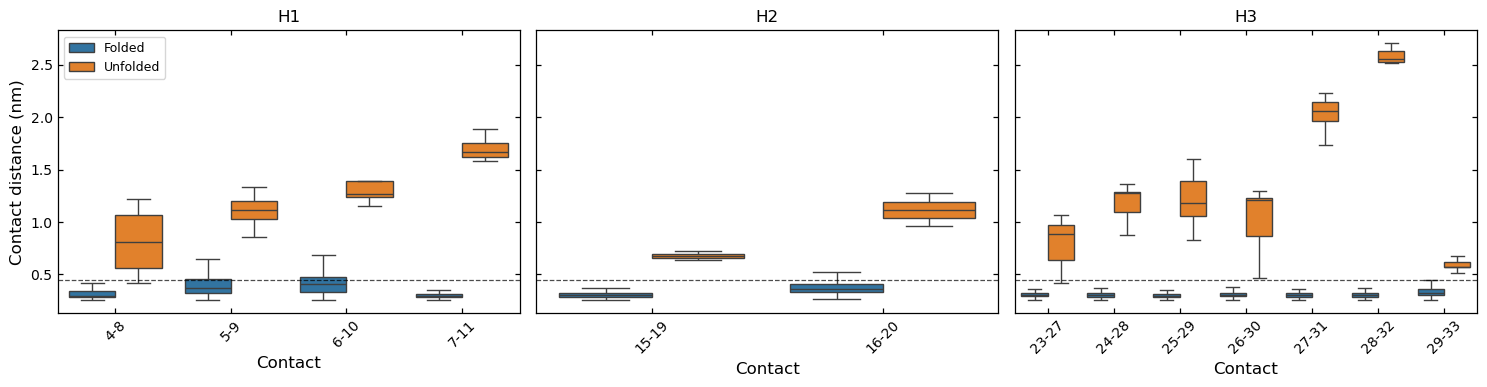

In [73]:
contact_cutoff = 0.45  # nm

fig, axs = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(15, 4),
    sharey=True
)

for ax, helix_name in zip(axs, ["H1", "H2", "H3"]):
    sub = df_contacts[df_contacts["Helix"] == helix_name]

    sns.boxplot(
        data=sub,
        x="Contact label",
        y="Distance",
        hue="Basin",
        showfliers=False,
        ax=ax
    )
    if helix_name == "H1":
        ax.legend(title="", loc="upper left")
    else:
        ax.get_legend().remove()

    ax.axhline(contact_cutoff, color="black", linestyle="--", linewidth=0.9, alpha=0.7)
    ax.set_title(helix_name)
    ax.set_xlabel("Contact")
    ax.set_ylabel("Contact distance (nm)")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()


plt.savefig("../output_figures/twostate_helix_differences.pdf", bbox_inches="tight")
plt.savefig("../output_figures/twostate_helix_differences.png", dpi=600, bbox_inches="tight")

### RMSD 

$$
\langle \mathrm{RMSD}\rangle_s
=
\frac{\sum_t \chi_s(t)\,\mathrm{RMSD}(t)}
{\sum_t \chi_s(t)}
$$

In [77]:
# ------------------------------------------------------------
# Fuzzy-weighted RMSD statistics
# ------------------------------------------------------------
average_rmsd_dict = {}
std_rmsd_dict = {}

for name in trajectories_labels:

    probabilities = np.asarray(
        pcca_probabilities_timeseries_dict[name],
        dtype=float
    )

    rmsd = np.asarray(rmsd, dtype=float)

    # Ensure that both arrays describe the same frames
    if probabilities.shape[0] != len(rmsd):
        raise ValueError(
            f"Length mismatch for {name}: "
            f"{probabilities.shape[0]} membership frames versus "
            f"{len(rmsd)} RMSD frames."
        )

    n_macrostates = 2

    average_rmsd_dict[name] = np.zeros(n_macrostates)
    std_rmsd_dict[name] = np.zeros(n_macrostates)

    for state in range(n_macrostates):

        if state == 0:
            weights = probabilities
        else:
            weights = 1 - probabilities

        # Ignore non-finite RMSD values, if present
        valid = np.isfinite(rmsd) & np.isfinite(weights)

        x = rmsd[valid]
        w = weights[valid]

        if w.sum() == 0:
            average_rmsd_dict[name][state] = np.nan
            std_rmsd_dict[name][state] = np.nan
            continue

        weighted_mean = np.average(x, weights=w)

        weighted_variance = np.average(
            (x - weighted_mean) ** 2,
            weights=w
        )

        average_rmsd_dict[name][state] = weighted_mean
        std_rmsd_dict[name][state] = np.sqrt(weighted_variance)

Plot

In [79]:

def weighted_quantile(values, quantiles, weights):
    """
    Compute weighted quantiles.

    Parameters
    ----------
    values : array-like
        Data values.
    quantiles : array-like
        Quantiles in [0, 1].
    weights : array-like
        Non-negative weights.
    """
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    weights = np.asarray(weights, dtype=float)

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights >= 0)
    )

    values = values[valid]
    weights = weights[valid]

    if len(values) == 0 or weights.sum() == 0:
        return np.full(len(quantiles), np.nan)

    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]

    cumulative_weights = np.cumsum(weights)
    cumulative_weights /= cumulative_weights[-1]

    return np.interp(
        quantiles,
        cumulative_weights,
        values
    )

In [81]:
rmsd_quantiles_dict = {}

for name in trajectories_labels:

    probabilities = np.asarray(
        pcca_probabilities_timeseries_dict[name],
        dtype=float
    )


    if probabilities.shape[0] != len(rmsd):
        raise ValueError(
            f"Length mismatch for {name}: "
            f"{probabilities.shape[0]} probabilities versus "
            f"{len(rmsd)} RMSD values."
        )

    n_states =  2

    rmsd_quantiles_dict[name] = {}

    for state in range(n_states):

        if state == 0:
            weights = probabilities
        else:
            weights = 1 - probabilities


        q10, q25, q50, q75, q90 = weighted_quantile(
            values=rmsd,
            quantiles=[0.10, 0.25, 0.50, 0.75, 0.90],
            weights=weights
        )

        rmsd_quantiles_dict[name][state] = {
            "q10": q10,
            "q25": q25,
            "median": q50,
            "q75": q75,
            "q90": q90
        }

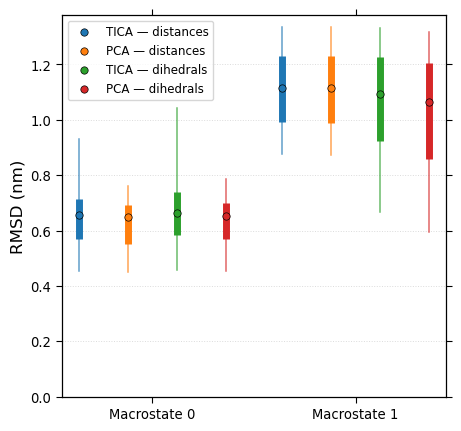

In [89]:
display_names = {
    "tica_distances": "TICA — distances",
    "pca_distances": "PCA — distances",
    "tica_dihedrals": "TICA — dihedrals",
    "pca_dihedrals": "PCA — dihedrals",
}


colors = {
    "tica_distances": "#1f77b4",
    "pca_distances": "#ff7f0e",
    "tica_dihedrals": "#2ca02c",
    "pca_dihedrals": "#d62728"
}

n_models = len(trajectories_labels)
n_states = len(rmsd_quantiles_dict[trajectories_labels[0]])

x = np.arange(n_states)

group_width = 0.72
offsets = np.linspace(
    -group_width / 2,
    group_width / 2,
    n_models
)

fig, ax = plt.subplots(
    figsize=(4.5, 4.2),
    constrained_layout=True
)

for i, name in enumerate(trajectories_labels):

    for state in range(n_states):

        stats = rmsd_quantiles_dict[name][state]
        xpos = x[state] + offsets[i]

        # Broad 10–90% interval
        ax.plot(
            [xpos, xpos],
            [stats["q10"], stats["q90"]],
            linewidth=1.1,
            color=colors[name],
            alpha=0.7,
            zorder=2
        )

        # Interquartile range
        ax.plot(
            [xpos, xpos],
            [stats["q25"], stats["q75"]],
            linewidth=5.0,
            color=colors[name],
            solid_capstyle="butt",
            zorder=3
        )

        # Weighted median
        ax.scatter(
            xpos,
            stats["median"],
            s=28,
            edgecolor="black",
            linewidth=0.5,
            color=colors[name],
            zorder=4,
            label=(
                display_names.get(name, name.replace("_", " "))
                if state == 0
                else None
            )
        )


ax.set_xticks(x)
ax.set_xticklabels(
    [f"Macrostate {state}" for state in range(n_states)]
)

ax.set_ylabel("RMSD (nm)")
ax.set_ylim(bottom=0)

ax.grid(
    axis="y",
    linestyle=":",
    linewidth=0.7,
    alpha=0.45,
    zorder=0
)

ax.set_axisbelow(True)

ax.tick_params(
    axis="both",
    direction="out",
    labelsize=9.5,
    length=4,
    width=0.8
)

ax.legend(
    frameon=True,
    fontsize=8.5,
    ncols=1,
    loc="upper left"
)

plt.savefig("../output_figures/twostate_fuzzy_weighted_rmsd_boxplot.pdf", bbox_inches="tight")
plt.savefig("../output_figures/twostate_fuzzy_weighted_rmsd_boxplot.png", dpi=600, bbox_inches="tight")
plt.show()